In [7]:
import os
from pathlib import Path
from abc import ABC
from dataclasses import dataclass
from enum import Enum
from typing import List, Optional, Dict, Callable
from collections import defaultdict, Counter
from fogvis.db import Database
from fogvis.common.math import VectorContainer3D
from contextlib import closing

import random

DB_PATH : Path = Path(os.path.abspath(os.path.join(os.getcwd(), os.pardir, os.pardir, "media", "db")))
db = Database(DB_PATH)

In [8]:
@dataclass
class MarchedVisibility: 
    mean : float
    median : float 
    minimum : float
    num_rays : int

@dataclass
class ComplexVisibility:
    including_invalid_rays : Optional[MarchedVisibility] = None
    excluding_invalid_rays : Optional[MarchedVisibility] = None

@dataclass
class ImageVisibility: 
    vis_simple : Optional[float] = None
    vis_marched : Optional[ComplexVisibility] = None 

class TimeOfDay(Enum):
    MORNING = "morning"
    NOON = "noon"
    EVENING = "evening"

def time_of_day_from_direction(direction_json: str) -> TimeOfDay:
    """
    Map a light direction vector to one of three times of day.
    The database currently contains three unique directional lights:
        (0, -1, 0) -> noon / overhead sun
        (0, 0, -1) -> morning / sun from the -z direction
        (0, 0, 1)  -> evening / sun from the +z direction
    """
    direction = VectorContainer3D.from_json(direction_json)
    x, y, z = direction.x, direction.y, direction.z
    if abs(y + 1.0) < 1e-6 and x == 0.0 and z == 0.0:
        return TimeOfDay.NOON
    if abs(z + 1.0) < 1e-6 and x == 0.0 and y == 0.0:
        return TimeOfDay.MORNING
    if abs(z - 1.0) < 1e-6 and x == 0.0 and y == 0.0:
        return TimeOfDay.EVENING
    raise ValueError(f"Unrecognized light direction: {direction_json}")

@dataclass
class RetreivedImageData:
    image_name : str
    fog_id : int
    vis_values : ImageVisibility
    time_of_day : TimeOfDay

@dataclass
class FogImage:
    image_path: str
    visibility: float
    time_of_day: TimeOfDay

@dataclass
class Dataset:
    images: List[FogImage]

class Experiment(ABC):
    def __init__(self, db: Database) -> None:
        self.db: Database = db

    def get_datasets(self) -> List[Dataset]:
        """Gathers a list of datasets to be used for training.
        Each item refers to a different set of data to be used in training a
        seperate instance of a model

        Returns:
            list: _description_
        """
        pass

def get_fog_images(
    db: Database, fog_type_name: str, scene_name: str
) -> list[RetreivedImageData]:
    result: list[RetreivedImageData] = []
    
    with db as con:
        ctx = con.cursor()
        sql: str = """SELECT image.fileName, fog.id AS fogID, visibility_distance.distanceType, visibility_distance.value, visibility_distance.average, visibility_distance.median, visibility_distance.minimum, visibility_distance.rayCount, light.virtualDirection FROM image
        INNER JOIN view ON view.colorImageID = image.id
        INNER JOIN camera ON view.cameraID = camera.id
        INNER JOIN scene ON view.sceneID = scene.id
        INNER JOIN environment ON view.environmentID = environment.id
        INNER JOIN fog ON environment.fogID = fog.id
        INNER JOIN fog_type ON fog.typeID = fog_type.id
        INNER JOIN environment_light ON environment.id = environment_light.environmentID
        INNER JOIN light ON environment_light.lightID = light.id
        INNER JOIN visibility_distance ON visibility_distance.viewID = view.id
            WHERE fog_type.name = ? AND
            scene.name = ? 
        """
        parms = (fog_type_name, scene_name)
        ctx.execute(sql, parms)
        res = ctx.fetchall()
        if len(res) == 0:
            raise Exception("Failed to get images for scene")

        visibilities : Dict[str, ImageVisibility] = {}
        time_of_days : Dict[str, TimeOfDay] = {}
        fog_ids : Dict[str, int] = {}

        for r in res:
            name : str = r[0]
            fog_id : int = r[1]
            mean : Optional[float] = None
            median : Optional[float] = None
            min : Optional[float] = None
            ray_count : Optional[int] = None
            direction_json : str = r[8]

            if name not in fog_ids:
                fog_ids[name] = fog_id
            else:
                if fog_ids[name] != fog_id:
                    raise Exception(f"Image {name} is associated with multiple fog bodies. This should not happen.")

            if name not in time_of_days:
                time_of_days[name] = time_of_day_from_direction(direction_json)
            else:
                if time_of_days[name] != time_of_day_from_direction(direction_json):
                    raise Exception(f"Image {name} is associated with multiple times of day. This should not happen.")

            if r[4] is not None: 
                mean = float(r[4])
            if r[5] is not None: 
                median = float(r[5])
            if r[6] is not None: 
                min = float(r[6])
            if r[7] is not None: 
                ray_count = int(r[7])

            if name not in visibilities: 
                visibilities[name] = ImageVisibility(None, None)
            
            if r[2] == "simple": 
                visibilities[name].vis_simple = float(r[3])
            elif r[2] == "ray_excluding_invalid": 
                if mean is not None and median is not None and min is not None and ray_count is not None: 
                    if visibilities[name].vis_marched is None: 
                        visibilities[name].vis_marched = ComplexVisibility(excluding_invalid_rays = MarchedVisibility(mean=mean, median=median, minimum=min, num_rays=ray_count))
                    else:
                        visibilities[name].vis_marched.excluding_invalid_rays = MarchedVisibility(mean=mean, median=median, minimum=min, num_rays=ray_count)

            elif r[2] == "ray_including_invalid":
                if (mean is not None and median is not None and min is not None and ray_count is not None): 
                    if visibilities[name].vis_marched is None:
                        visibilities[name].vis_marched = ComplexVisibility(including_invalid_rays = MarchedVisibility(mean=mean, median=median, minimum=min, num_rays=ray_count))
                    else:
                        visibilities[name].vis_marched.including_invalid_rays = MarchedVisibility(mean=mean, median=median, minimum=min, num_rays=ray_count)
                else:
                    raise Exception(f"Failed to parse distance metrics for image. This should not happen.")

        for file_name in visibilities: 
            result.append(RetreivedImageData(image_name=file_name, fog_id=fog_ids[file_name], vis_values=visibilities[file_name], time_of_day=time_of_days[file_name]))

    return result

RetrievedFilter = Callable[[List[RetreivedImageData]], List[RetreivedImageData]]
FogConverter = Callable[[RetreivedImageData, Path], FogImage]

def filter_has_simple_visibility(data: List[RetreivedImageData]) -> List[RetreivedImageData]:
    return [d for d in data if d.vis_values.vis_simple is not None]

def filter_has_marched_excluding_invalid(data: List[RetreivedImageData]) -> List[RetreivedImageData]:
    return [
        d for d in data
        if d.vis_values.vis_marched is not None and d.vis_values.vis_marched.excluding_invalid_rays is not None
    ]

def balance_by_time_of_day_by_image(seed: Optional[int] = None) -> RetrievedFilter:
    """
    Randomly downsample each time-of-day bucket so all buckets have the same number of images.
    """
    def _filter(data: List[RetreivedImageData]) -> List[RetreivedImageData]:
        if seed is not None:
            random.seed(seed)
        by_tod = defaultdict(list)
        for d in data:
            by_tod[d.time_of_day].append(d)
        if not by_tod:
            return []
        target = min(len(items) for items in by_tod.values())
        balanced : List[RetreivedImageData] = []
        for items in by_tod.values():
            if len(items) <= target:
                balanced.extend(items)
            else:
                balanced.extend(random.sample(items, target))
        return balanced
    return _filter

def balance_by_time_of_day_by_fog_body(seed: Optional[int] = None) -> RetrievedFilter:
    """
    Ensure each time-of-day bucket contains images from the same set of fog bodies.
    Only fog bodies that appear under every time of day are kept.
    """
    def _filter(data: List[RetreivedImageData]) -> List[RetreivedImageData]:
        if seed is not None:
            random.seed(seed)
        by_tod = defaultdict(lambda: defaultdict(list))
        for d in data:
            by_tod[d.time_of_day][d.fog_id].append(d)
        if not by_tod:
            return []
        common_bodies = set.intersection(*(set(bodies.keys()) for bodies in by_tod.values()))
        if not common_bodies:
            return []
        balanced : List[RetreivedImageData] = []
        for tod, bodies in by_tod.items():
            for body in common_bodies:
                images = bodies[body]
                balanced.extend(images)
        return balanced
    return _filter

def build_dataset(
    db: Database,
    fog_type_name: str,
    scene_name: str,
    filters: List[RetrievedFilter],
    converter: FogConverter,
) -> Dataset:
    raw = get_fog_images(db, fog_type_name, scene_name)
    for f in filters:
        raw = f(raw)
    return Dataset(images=[converter(d, db.import_dir) for d in raw])

def linear_converter(data: RetreivedImageData, import_dir: Path) -> FogImage:
    return FogImage(
        image_path=os.path.join(import_dir, data.image_name),
        visibility=float(data.vis_values.vis_simple),
        time_of_day=data.time_of_day,
    )

def exponential_converter(data: RetreivedImageData, import_dir: Path) -> FogImage:
    return FogImage(
        image_path=os.path.join(import_dir, data.image_name),
        visibility=float(data.vis_values.vis_simple),
        time_of_day=data.time_of_day,
    )

def marched_converter(data: RetreivedImageData, import_dir: Path) -> FogImage:
    return FogImage(
        image_path=os.path.join(import_dir, data.image_name),
        visibility=float(data.vis_values.vis_marched.excluding_invalid_rays.mean),
        time_of_day=data.time_of_day,
    )

class Basic_Synthetic_Quality(Experiment):
    def __init__(self, db: Database) -> None:
        super().__init__(db)

    def get_datasets(self) -> List[Dataset]:
        return [
            build_dataset(
                self.db, "linear", "berthoud_pass_co",
                filters=[filter_has_simple_visibility],
                converter=linear_converter,
            ),
            build_dataset(
                self.db, "exponential", "berthoud_pass_co",
                filters=[filter_has_simple_visibility],
                converter=exponential_converter,
            ),
            build_dataset(
                self.db, "marched", "berthoud_pass_co",
                filters=[
                    filter_has_marched_excluding_invalid,
                    balance_by_time_of_day_by_fog_body(seed=42),
                ],
                converter=marched_converter,
            ),
        ]
    
    def get_validation_dataset(self) -> Dataset: 
        return build_dataset(
            self.db, "marched", "berthoud_pass_co",
            filters=[filter_has_marched_excluding_invalid],
            converter=marched_converter,
        )
    
experiment : Basic_Synthetic_Quality = Basic_Synthetic_Quality(db)
datasets = experiment.get_datasets()
validation = experiment.get_validation_dataset()

## Demo Stuff
This code is just for showing what is in the dataset and making sure paths are correct

### Helpers

In [9]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random
import math
from collections import Counter

def display_image(img : FogImage) -> None: 
    i = mpimg.imread(img.image_path)
    plt.imshow(i)
    plt.axis('off')
    plt.title(f'Distance: {img.visibility} meters')
    plt.show()
    

def plot_visibility_classes(dataset):
    """
    Plot a bar graph showing the number of images in each visibility class.

    Each class is the floored number of miles of visibility.
    Example:
        0.3 miles -> class 0
        1.9 miles -> class 1
        5.0 miles -> class 5

    Parameters
    ----------
    dataset : Dataset
        A Dataset object containing a list of FogImage objects.
    """

    METERS_PER_MILE = 1609.344

    visibility_classes = []

    for image in dataset.images:
        try:
            vis_meters = float(image.visibility)
        except ValueError:
            print(f"Skipping invalid visibility value: {image.visibility}")
            continue

        vis_miles = vis_meters / METERS_PER_MILE
        vis_class = math.floor(vis_miles)

        visibility_classes.append(vis_class)

    class_counts = Counter(visibility_classes)

    if not class_counts:
        print("No valid visibility distances found.")
        return

    # Sort classes by visibility distance
    classes = sorted(class_counts.keys())
    counts = [class_counts[c] for c in classes]

    plt.figure(figsize=(10, 6))
    plt.bar(classes, counts)

    plt.xlabel("Visibility Class, Floored Miles")
    plt.ylabel("Number of Images")
    plt.title("Number of Fog Images by Visibility Distance")

    plt.xticks(classes)
    plt.grid(axis="y", alpha=0.3)

    plt.show()


### Datasets

Linear Images

In [10]:
lin = datasets[0]
exp = datasets[1]
marched = datasets[2]

In [11]:
print(f"Num Linear Images: {len(lin.images)}")
print(f"Num Exp Images: {len(exp.images)}")
print(f"Num Marched Images: {len(marched.images)}")

Num Linear Images: 14400
Num Exp Images: 14400
Num Marched Images: 2647


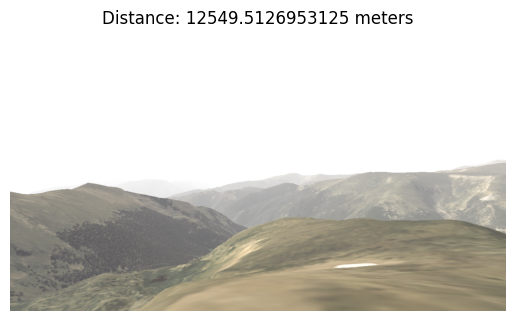

In [12]:
test_image : FogImage = random.choice(lin.images)
display_image(test_image)

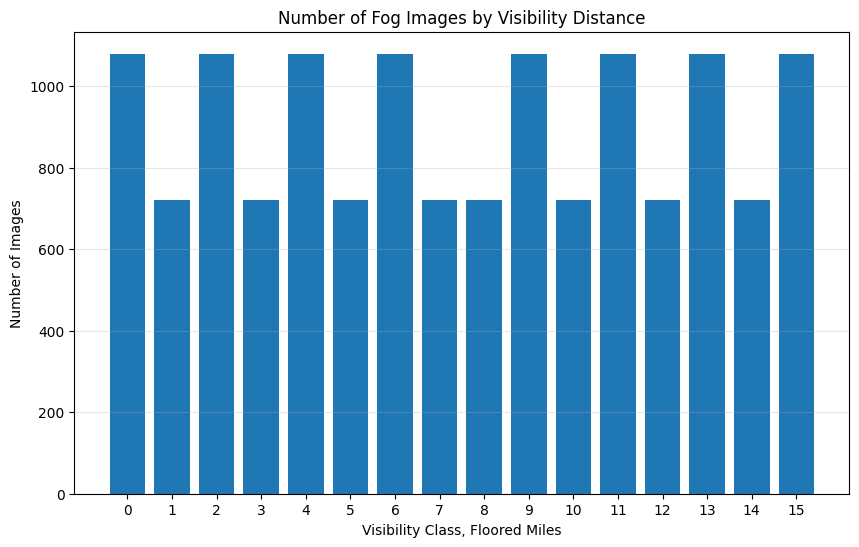

In [13]:
plot_visibility_classes(lin)

Exponential Images

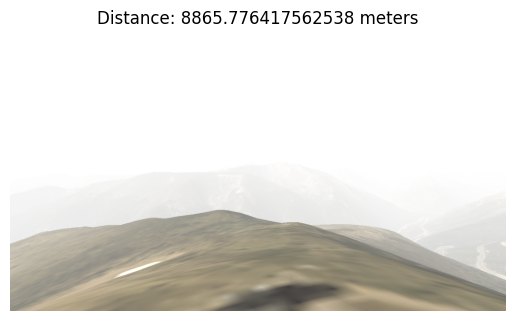

In [14]:
test_image : FogImage = random.choice(exp.images)
display_image(test_image)

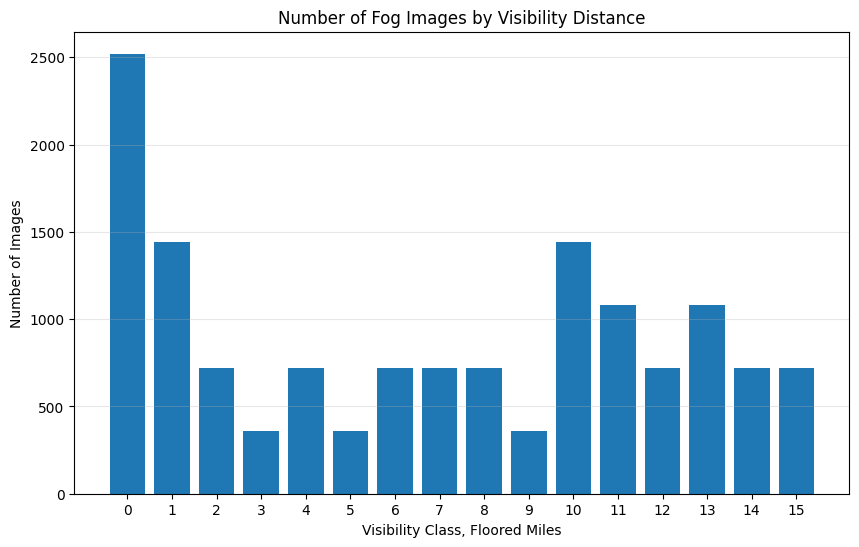

In [15]:
plot_visibility_classes(exp)

Marched

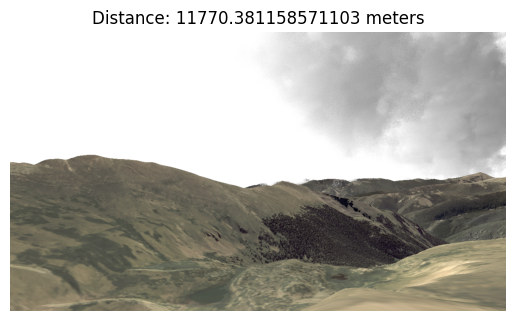

In [16]:
test_image : FogImage = random.choice(marched.images)
display_image(test_image)

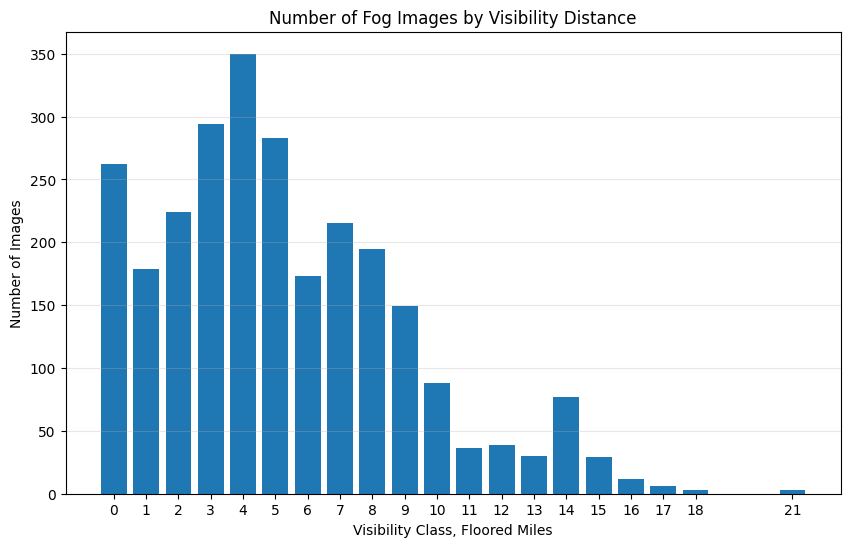

In [17]:
plot_visibility_classes(marched)